# Feldman Cousin Confidence Intervals and Neutrino Oscillations

Often in physics we deal with event counts. For example detecting the number of decaying particles, or perhaps photons coming from some interstellar object, or exotic and rare event signals, all of this requires counting number of events. Often these events are fundamentally random. For example a cosmic ray coming to your detector, would have a distribution around what is the emphirical expectation! Now since these events are random in time, in a given time bin you can say that the probability of observing one particle is $p$ vs not observing any particle is $1-p$. So the total count becomes a binomial distribution. If then this bin interval becomes infinitesimally small you will end up with the poisson distribution,
$$P(n) = \frac{\lambda^n e^{-\lambda}}{n!}$$
Now suppose you expect the true signal to be $\mu_{\text{true}}$, and there exists a background $b$, then your total expection comes out to be $\lambda=\mu_{\text{true}}+b$. Of course when we are measuring this, we can never with 100% confidence know what this signal value is, so we have to quote a confidence interval which was well studied in the last tutorial. There however exists a pesky issue with this approach. When $\mu_{\text{true}}\sim 0$, you will notice that the classical confidence interval breaks down. To understand this consider,

$$\mu_{\text{true}} = 0$$

and the known background is,

$$b=3$$

Then the exepcted observation become,

$$\lambda = \mu_{\text{true}}+b = 3$$

So then even if there is no signal your detector will still typically observe the background. Sometimes you'll observe fewer events than the expected background because of the same Poisson statistical fluctuation, lets say $n=1$. Then using the natural estimator you'll conclude,

$$\hat{\mu} = 1-3 = -2$$

Immediately we have a problem! A negative signal is physically meaningless. Now you'll think let us just replace the negative values with zero. If you do so then your confidence interval area is no longer what you initially wanted it to be, because you have changed you lower interval. This demands the upper interval be changed correspondingly. Feldman and Cousins saw this problem running wild in statistical analysis and decided to solve it once and for all. Today we will try to replicate their procedure to find robust confidence intervals!

We shall shift from asking "how probable is the observation?" to "which hypothesis fits this observation the best?". Of course by now we have not done much of hypothsis testing, however the basic idea lies in understanding how likely is a hypothesis compared to the best hypothesis that my theory predicts? In this context this means to check for a given $\mu$, what values of $n$ are more likely to be inside the 90% confidence interval. We check that by first calculating,

$$R=(n;\mu) = \frac{P(n|\mu)}{P(n|\hat{\mu})}$$

for all $n$, where $\hat{\mu}=\max(0,n-b)$, and then ranking $n$ accordingly to choose the top values whose probability add up to 90%. That would fix the lower limit issue while not destroying the upper limit coverage.


In [1]:
import numpy as np
from scipy.stats import poisson
from array import array
import matplotlib.pyplot as plt

# Feel free to add more packages if you need them!

For our example we will take $\mu_{\text{true}}\in [0,20]$ and keep a background of 3. Your job is to build the Poisson probability mass function that for a given $n$ and $\mu$ returns the corresponding probability with the background.

In [2]:
mu_true = np.linspace(0, 20, 21)
bkg = 3

def Poisson(n,mu):
    ### YOUR CODE HERE
    mu = mu + bkg
    p = poisson.pmf(n, mu)
    return p

If you have done that successfully I want you to define a function, which when supplied with a probability array for different values of $n$ given $\hat{\mu}$, can return the first index where the cumulative probability is equal to or just crossed 90%.

In [3]:
def coverage_limit_index(probability_array):
    ### YOUR CODE HERE
    cumulative_sum = 0
    cumulative_sum_array = [0]
    result_array = []
    for i in range(len(probability_array)):
        cumulative_sum += probability_array[i]
        cumulative_sum_array.append(cumulative_sum)
        print(f"{cumulative_sum} : {cumulative_sum_array[i]}")
        if ((cumulative_sum <= 0.9) or ((cumulative_sum > 0.9) and (cumulative_sum_array[i]<=0.9))):
            result_array.append(probability_array[i])
    return len(result_array)-1

Now that we have the functions ready try to replicate the logic that was discussed above. Practically it is not necessary to look for $n$ beyond 40 as the probability of that would be very small for the signal considered. Remember first you need to calculate the poisson PMF for a given $n$, then find the best fit $\hat{mu}$, after which you should calculate the likelihood ratio for the $\mu$ hypothesis and sort out the corresponding PMFs and $n$ in descending order of the likelihood ratio. From this sorted probability PMF you will then be able to find the 90% coverage index using the function that you have defined above. Finally for every $\mu$ store the corresponding upper and lower limit by finding the maximum and minimum $n$ within the selected indices.

In [4]:
Lower_limit = []
Upper_limit = []

for mu in mu_true:
        n = np.arange(0,40)
        ### YOUR CODE HERE
        mu_best = np.maximum(0, n-bkg)
        Prob = Poisson(n,mu)
        R = Prob/Poisson(n,mu_best)
        index = np.argsort(R)[::-1] ### descending order sort is done by ::-1
        Sort_Prob = Prob[index]
        End_point = coverage_limit_index(Sort_Prob)

        ### This extracts the elements of n in the order specified by index from the beginning up to End_point + 1.
        n_bound = n[index][:End_point+1]  
        upper_limit = np.max(n_bound)
        lower_limit = np.min(n_bound)
        Lower_limit.append(lower_limit)
        Upper_limit.append(upper_limit)

0.22404180765538775 : 0
0.4480836153107755 : 0.22404180765538775
0.5974448204143674 : 0.4480836153107755
0.6472318887822314 : 0.5974448204143674
0.8152632445237722 : 0.6472318887822314
0.9160820579686968 : 0.8152632445237722
0.966491464691159 : 0.9160820579686968
0.9880954961436428 : 0.966491464691159
0.9961970079383242 : 0.9880954961436428
0.9988975118698847 : 0.9961970079383242
0.9997076630493529 : 0.9988975118698847
0.999928613371026 : 0.9997076630493529
0.9999838509514443 : 0.999928613371026
0.999996598085387 : 0.9999838509514443
0.999999329614089 : 0.999996598085387
0.9999998759198294 : 0.999999329614089
0.9999999783521557 : 0.9999998759198294
0.9999999964284486 : 0.9999999783521557
0.9999999994411641 : 0.9999999964284486
0.9999999999168561 : 0.9999999994411641
0.9999999999882099 : 0.9999999999168561
0.9999999999984033 : 0.9999999999882099
0.9999999999997933 : 0.9999999999984033
0.9999999999999746 : 0.9999999999997933
0.9999999999999972 : 0.9999999999999746
0.9999999999999999 : 0.

If you did all that correctly, you should check the following plotting code!

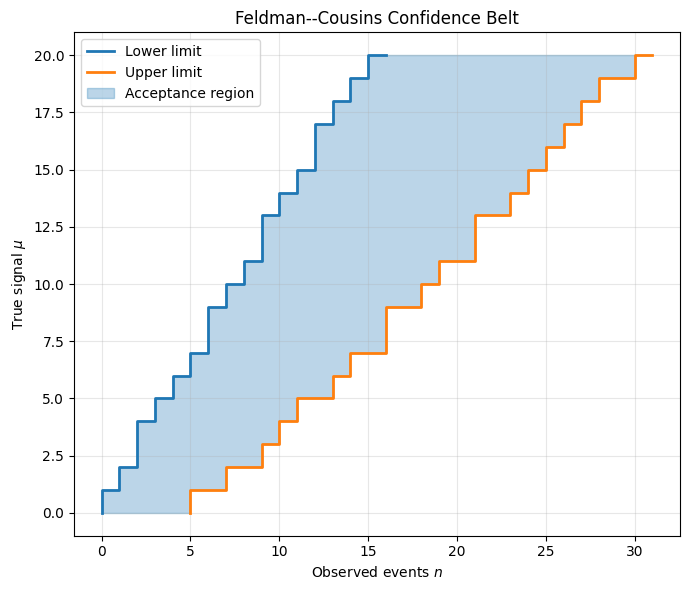

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Lower and upper boundaries of the confidence belt
plt.step(Lower_limit, mu_true, lw=2, label='Lower limit')
plt.step(Upper_limit, mu_true, lw=2, label='Upper limit')

# Shade the acceptance region
plt.fill_betweenx(mu_true, Lower_limit, Upper_limit,
                  step='post', alpha=0.3, color='C0',
                  label='Acceptance region')

plt.xlabel(r'Observed events $n$')
plt.ylabel(r'True signal $\mu$')
plt.title('Feldman--Cousins Confidence Belt')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Great it seems that you have a hang of this now. Let us try to apply it to some real examples. Neutrinos come is three flavour, electron neutrino $\nu_e$, muon neutrino $\nu_\mu$ and tau neutrino $\nu_\tau$. These neutrinos cannot be detected in mass eigenstate due to charged current interactions at detection. As a consequence they oscillate into each other. Given below is the probability of one of such oscillation channels,

$$P(\nu_\mu\to\nu_e) = \sin^2 2\theta\sin^2\left(1.27\frac{\Delta m^2 L}{E}\right)$$

Now assume that there is a beamline experiment set at an energy and length such that,

$$1.27\frac{\Delta m^2 L}{E}=\frac{\pi}{2}$$

However the detector has a 10% efficiency. Now assume the beam signal count comes to 1000 muon neutrinos and suppose the experiment has observed $n=12$ electron neutrinos. Your next task is the estimate how many muon neutrinos oscillated to electron neutrinos and put a bound on $\theta$. Assume the background expectation to be 3.

In [13]:
### YOUR CODE HERE
num_obs = 12
mu_up = np.array(mu_true)[np.array(Lower_limit) >= num_obs][np.argmin(np.abs(np.array(Lower_limit)[np.array(Lower_limit) >= num_obs] - num_obs))]
mu_low = np.array(mu_true)[np.array(Upper_limit) >= num_obs][np.argmin(np.abs(np.array(Upper_limit)[np.array(Upper_limit) >= num_obs] - num_obs))]

print(mu_low * 10, mu_up * 10)

theta_low = 0.5 * np.arcsin(np.sqrt(mu_low)/10)
theta_up = 0.5 * np.arcsin(np.sqrt(mu_up)/10)

print(theta_low, theta_up)

50.0 150.0
0.11275670294906562 0.1988497075460359


Now consider two more experiments which saw $n=1$ and $n=3$. Calculate the corresponding bound on $\theta$. Can you tell out of these three experiment which one most likely to be wrong and why?

In [15]:
### YOUR CODE HERE
num_obs = 1
mu_up = np.array(mu_true)[np.array(Lower_limit) >= num_obs][np.argmin(np.abs(np.array(Lower_limit)[np.array(Lower_limit) >= num_obs] - num_obs))]
mu_low = np.array(mu_true)[np.array(Upper_limit) >= num_obs][np.argmin(np.abs(np.array(Upper_limit)[np.array(Upper_limit) >= num_obs] - num_obs))]

print(mu_low * 10, mu_up * 10)

theta_low = 0.5 * np.arcsin(np.sqrt(mu_low)/10)
theta_up = 0.5 * np.arcsin(np.sqrt(mu_up)/10)

print(theta_low, theta_up)

num_obs = 3
mu_up = np.array(mu_true)[np.array(Lower_limit) >= num_obs][np.argmin(np.abs(np.array(Lower_limit)[np.array(Lower_limit) >= num_obs] - num_obs))]
mu_low = np.array(mu_true)[np.array(Upper_limit) >= num_obs][np.argmin(np.abs(np.array(Upper_limit)[np.array(Upper_limit) >= num_obs] - num_obs))]

print(mu_low * 10, mu_up * 10)

theta_low = 0.5 * np.arcsin(np.sqrt(mu_low)/10)
theta_up = 0.5 * np.arcsin(np.sqrt(mu_up)/10)

print(theta_low, theta_up)

0.0 10.0
0.0 0.0500837105807799
0.0 40.0
0.0 0.1006789603951654
